In [1]:
import pandas as pd
import h5py
import matplotlib.pyplot as plt
import numpy as np
import corner
from copy import deepcopy
from matplotlib import gridspec
import matplotlib.lines as mlines
import glob
from tqdm import tqdm
import deepdish as dd

from scipy.stats import dirichlet
sys.path.append('../')

import populations.bbh_models as read_models
from populations import gw_obs


/data/wiay/2297403c/conda_envs/amaze/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
chi_b = [0.,0.1,0.2,0.5]
alpha = [0.2,0.5,1.,2.,5.]

flowfile='/data/wiay/2297403c/amaze_model_select/AMAZE_project_resources/test_production_runs/continuous_GWTC-3/output_seed12.hdf5'
flow_result = h5py.File(f'{flowfile}', 'r')
hyper_posts = np.array(flow_result['model_selection']['samples']['block0_values'])
hyperpost_samp = hyper_posts[3973,:]

In [10]:
hyper_posts[3974,:]

array([3.67087937e-02, 4.57156346e+00, 9.33316293e-01, 1.38352987e-02,
       2.88116974e-03, 1.50010134e-02, 3.49662249e-02])

In [3]:

file_path='/data/wiay/2297403c/models_reduced.hdf5'
params = ['mchirp','q', 'chieff', 'z']
channels =['CE', 'CHE', 'GC', 'NSC', 'SMT']

model_names, flow = read_models.get_models(file_path, channels, params, use_flows=True, device='cpu',\
     sensitivity='midhighlatelow', flow_path=flowfile)

for channel in channels:
     flow[channel].load_model('/data/wiay/2297403c/amaze_model_select/AMAZE_project_resources/test_production_runs/flows_prod_tests/flow_models/')   

100%|██████████| 5/5 [01:24<00:00, 16.96s/it]


In [10]:
np.shape(hyper_posts)

(128000, 7)

In [54]:
#For single hyperposterior sample
hyperpost_samp = hyper_posts[3974,:]
no_total_samps = 1000001
total_samps = np.zeros((no_total_samps,len(params)))

samps_filled = np.zeros(6, dtype=int)

for cidx, channel in enumerate(channels):
    print(f'sampling {channel}...')
    no_channel_samps = int(np.round(no_total_samps*hyperpost_samp[2+cidx], decimals=0))
    print(no_channel_samps)
    if channel == 'CE':
        hyperpost_samp[1] = np.log(hyperpost_samp[1])
        channel_samps = flow[channel].flow.sample(np.array([hyperpost_samp[:2]]), no_channel_samps)
    else:
        channel_samps = flow[channel].flow.sample(np.array([hyperpost_samp[:1]]), no_channel_samps)

    channel_samps[:,0] = flow[channel].expistic(channel_samps[:,0], flow[channel].mappings[0], flow[channel].mappings[1])
    channel_samps[:,1] = flow[channel].expistic(channel_samps[:,1], flow[channel].mappings[2])
    channel_samps[:,2] = np.tanh(channel_samps[:,2])
    channel_samps[:,3] = flow[channel].expistic(channel_samps[:,3], flow[channel].mappings[4], flow[channel].mappings[5])
    
    total_samps[samps_filled[cidx-1]:samps_filled[cidx-1]+no_channel_samps,:] = channel_samps
    samps_filled[cidx]=samps_filled[cidx-1]+no_channel_samps


sampling CE...
933317
sampling CHE...
13835
sampling GC...
2881
sampling NSC...
15001
sampling SMT...
34966


In [17]:
#Marginalising over hyperposterior samples
no_total_samps = 100000
samps_per_hyperposts = 10
no_hypersamps = int(no_total_samps/samps_per_hyperposts)
total_samps = np.zeros((no_total_samps,len(params)))

samps_filled = np.zeros(6, dtype=int)
channel_samps = [[],[],[],[],[]]

for i, hyperpost_idx in enumerate(tqdm(np.random.choice(np.arange(np.shape(hyper_posts)[0]), no_hypersamps, replace=False))):
    hyperpost_samp = hyper_posts[hyperpost_idx,:]

    #evauluate channel as weighted choice according to branching fractions
    channel_idx = np.random.choice(np.arange(len(channels)), p=hyperpost_samp[2:])
    channel = channels[channel_idx]

    #sample flow
    if channel == 'CE':
        hyperpost_samp[1] = np.log(hyperpost_samp[1])
        total_samps[i*(samps_per_hyperposts):(i+1)*(samps_per_hyperposts),:] = flow[channel].flow.sample(np.array([hyperpost_samp[:2]]), samps_per_hyperposts)
    else:
        total_samps[i*(samps_per_hyperposts):(i+1)*(samps_per_hyperposts),:] = flow[channel].flow.sample(np.array([hyperpost_samp[:1]]), samps_per_hyperposts)

    total_samps[i*(samps_per_hyperposts):(i+1)*(samps_per_hyperposts),0] = flow[channel].expistic(total_samps[i*(samps_per_hyperposts):(i+1)*(samps_per_hyperposts),0], flow[channel].mappings[0], flow[channel].mappings[1])
    total_samps[i*(samps_per_hyperposts):(i+1)*(samps_per_hyperposts),1] = flow[channel].expistic(total_samps[i*(samps_per_hyperposts):(i+1)*(samps_per_hyperposts),1], flow[channel].mappings[2])
    total_samps[i*(samps_per_hyperposts):(i+1)*(samps_per_hyperposts),2] = np.tanh(total_samps[i*(samps_per_hyperposts):(i+1)*(samps_per_hyperposts),2])
    total_samps[i*(samps_per_hyperposts):(i+1)*(samps_per_hyperposts),3] = flow[channel].expistic(total_samps[i*(samps_per_hyperposts):(i+1)*(samps_per_hyperposts),3], flow[channel].mappings[4], flow[channel].mappings[5])
    
    channel_samps[channel_idx].append(total_samps[i*(samps_per_hyperposts):(i+1)*(samps_per_hyperposts),:])
no_channel_samps = [np.shape(channel_samps[chnl])[0] for chnl in np.arange(len(channels))]
samps_filled[:5] = np.cumsum(no_channel_samps, axis=0)*samps_per_hyperposts

100%|██████████| 10000/10000 [01:23<00:00, 119.27it/s]


In [20]:
#ordering total samples by channel
total_samps_ordered = np.zeros((no_total_samps, len(params)))

for cidx in range(len(channels)):
    channel_samps_red = np.reshape(np.array(channel_samps[cidx]),(-1,len(params)))
    total_samps_ordered[samps_filled[cidx-1]:samps_filled[cidx],:] = channel_samps_red

In [31]:
corner_kwargs = dict(
    bins=64,
    smooth=0.9,
    color="teal",
    #quantiles=[0.16, 0.84],
    levels=(1 - np.exp(-0.5), 1 - np.exp(-2), 1 - np.exp(-9 / 2.0)),
    #plot_density=True,
    plot_datapoints=True,
    fill_contours=True,
    show_titles=True,
    #hist_kwargs=dict(density=True),
    labels=['mchirp','q','chieff','z']
)
kwargs = deepcopy(corner_kwargs)
kwargs["color"] = "C1"

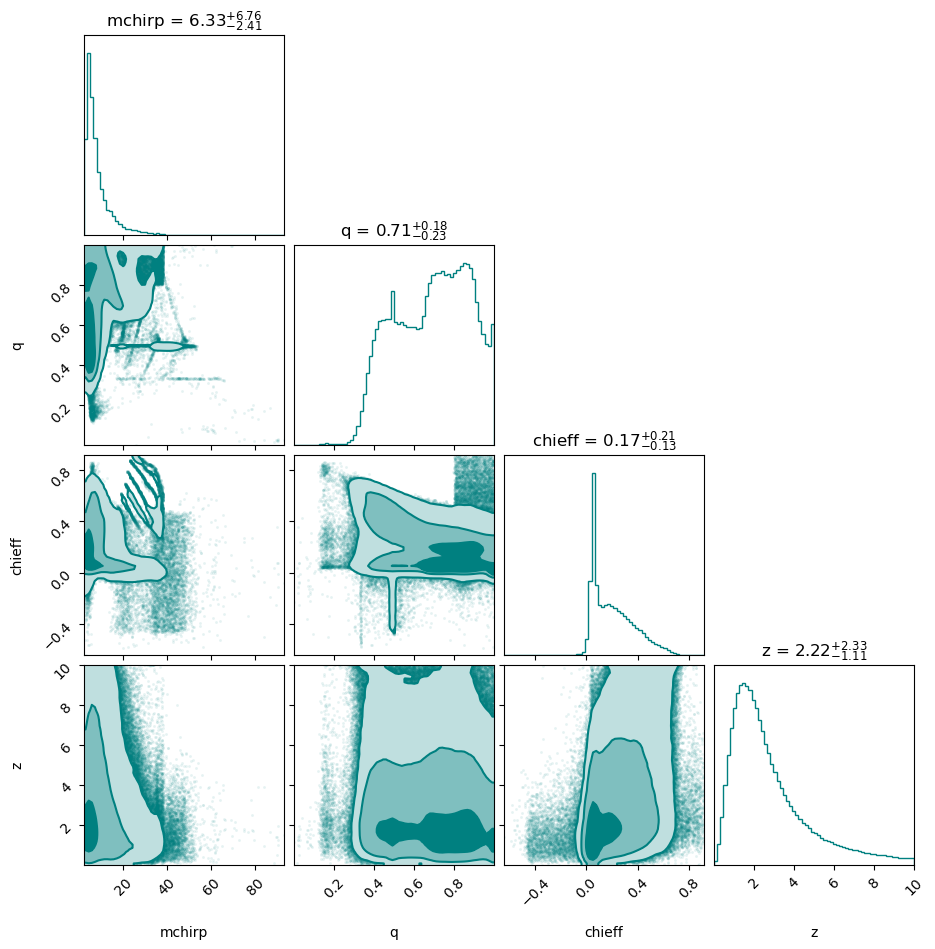

In [32]:
fig = corner.corner(total_samps_ordered[:-1, :], **corner_kwargs)


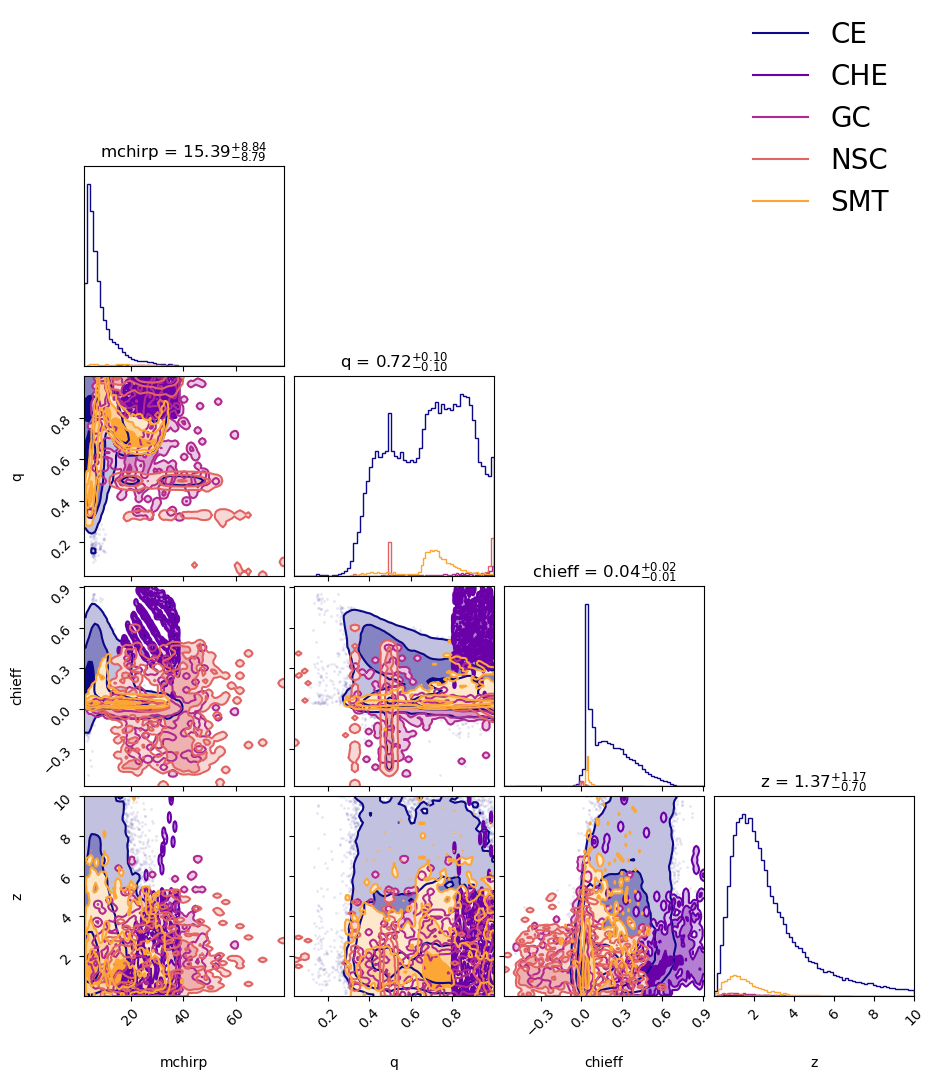

In [12]:
cmap = plt.colormaps['plasma']
colors = cmap(np.linspace(0, 1, 6))
corner_kwargs = dict(
    bins=64,
    smooth=0.9,
    color=colors[0],
    #quantiles=[0.16, 0.84],
    levels=(1 - np.exp(-0.5), 1 - np.exp(-2), 1 - np.exp(-9 / 2.0)),
    plot_density=False,
    plot_datapoints=True,
    fill_contours=True,
    show_titles=True,
    labels=['mchirp','q','chieff','z'],
)


fig=corner.corner(total_samps[samps_filled[-1]:samps_filled[0]], **corner_kwargs)

for cidx, channel in enumerate(channels[1:]):
    corner_kwargs["color"] = colors[cidx+1]
    corner.corner(total_samps_ordered[samps_filled[cidx]:samps_filled[cidx+1]], fig=fig, **corner_kwargs)
plt.legend(
        handles=[
            mlines.Line2D([], [], color=colors[i], label=channels[i])
            for i in range(5)
        ],
        fontsize=20, frameon=False,
        bbox_to_anchor=(1, 5), loc="upper right"
    )

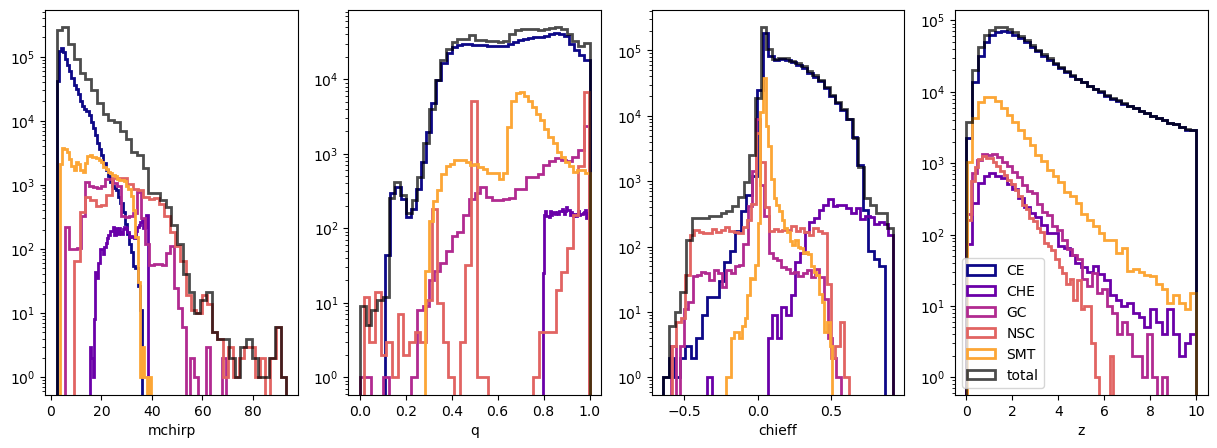

In [34]:
plt.rcParams["figure.figsize"] = (15,5)
fig,ax=plt.subplots(1,4)
cmap = plt.colormaps['plasma']
colors = cmap(np.linspace(0, 1, 6))

for cidx, channel in enumerate(channels):
    for pidx,param in enumerate(params):
        ax[pidx].hist(total_samps_ordered[samps_filled[cidx-1]:samps_filled[cidx],pidx], color=colors[cidx], histtype='step', bins=40, lw=2,\
             label=channel)
        ax[pidx].set_yscale('log')
        ax[pidx].set_xlabel(param)

for pidx,param in enumerate(params):
    ax[pidx].hist(total_samps_ordered[:,pidx], color='black', histtype='step', bins=40, lw=2, ls='-', label='total', alpha=0.7)
plt.legend()

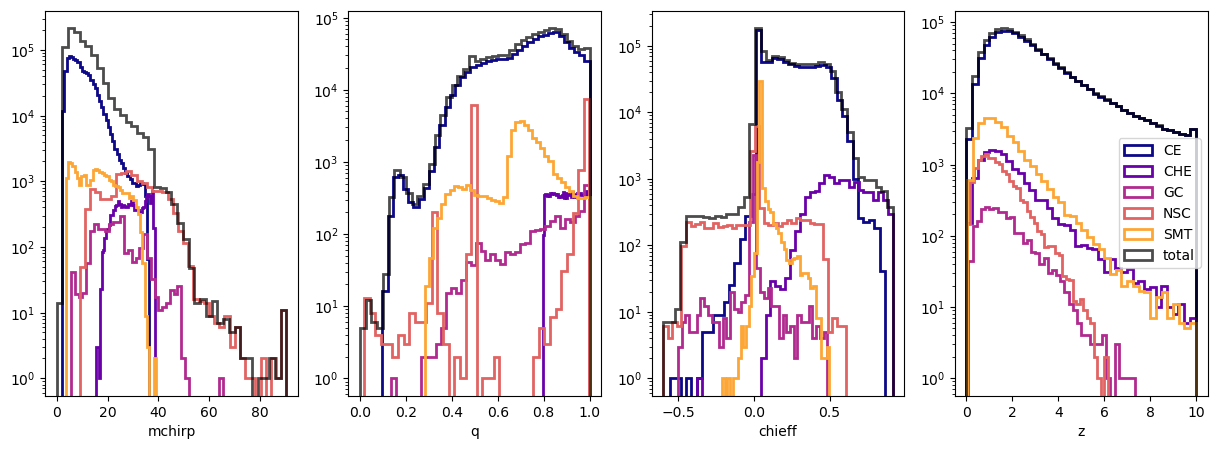

In [55]:
plt.rcParams["figure.figsize"] = (15,5)
fig,ax=plt.subplots(1,4)
cmap = plt.colormaps['plasma']
colors = cmap(np.linspace(0, 1, 6))

for cidx, channel in enumerate(channels):
    for pidx,param in enumerate(params):
        ax[pidx].hist(total_samps[samps_filled[cidx-1]:samps_filled[cidx],pidx], color=colors[cidx], histtype='step', bins=40, lw=2,\
             label=channel)
        ax[pidx].set_yscale('log')
        ax[pidx].set_xlabel(param)

for pidx,param in enumerate(params):
    ax[pidx].hist(total_samps[:,pidx], color='black', histtype='step', bins=40, lw=2, ls='-', label='total', alpha=0.7)
plt.legend()

In [8]:
#samples from gravitiy spy generation
comb_intrins_samps = pd.read_hdf('/data/wiay/2297403c/GW_ChirpSim/binary_param_generation/60_intrins_samps_zmax1_35.hdf5', key='all_intrins_samps')

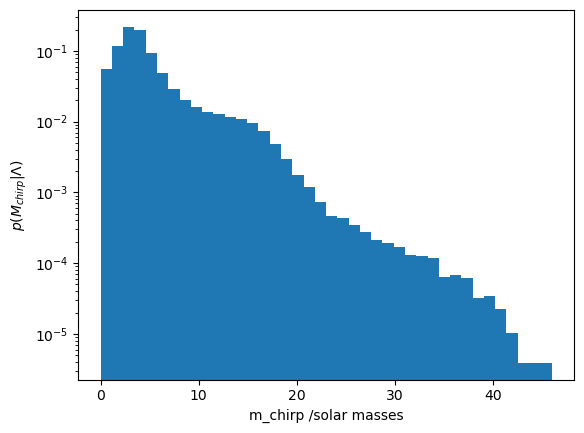

In [18]:
mchirp_samps = comb_intrins_samps['m1']*(comb_intrins_samps['q']**3/(1+comb_intrins_samps['q']))
plt.hist(mchirp_samps, density=True, bins=40)
plt.xlabel('m_chirp /solar masses')
plt.ylabel(r'$p(M_{chirp}|\Lambda)$')
plt.yscale('log')

In [23]:
chieff_samps = ((comb_intrins_samps['chi_1']*comb_intrins_samps['costilt_1'])+(comb_intrins_samps['q']*comb_intrins_samps['chi_2']*comb_intrins_samps['costilt_2']))\
    /(1+comb_intrins_samps['q'])

(array([1.14222147e-04, 1.14222147e-04, 2.28444294e-04, 2.28444294e-04,
        1.14222147e-04, 1.14222147e-04, 6.85332881e-04, 6.85332881e-04,
        1.25644361e-03, 1.94177650e-03, 2.74133152e-03, 2.51288723e-03,
        3.65510870e-03, 4.79733017e-03, 6.85332881e-03, 7.08177310e-03,
        1.01657711e-02, 1.55342120e-02, 1.83897656e-02, 2.46719837e-02,
        3.16395347e-02, 4.38613044e-02, 5.35701869e-02, 6.30506250e-02,
        8.12119464e-02, 1.07026152e-01, 1.24730584e-01, 1.56141675e-01,
        1.89608764e-01, 2.47176726e-01, 2.89781586e-01, 3.55459321e-01,
        4.35757490e-01, 5.22566322e-01, 6.19084036e-01, 7.25310632e-01,
        8.68202538e-01, 1.02422999e+00, 1.18505477e+00, 1.41818217e+00,
        1.66912823e+00, 1.93435206e+00, 2.26342606e+00, 2.60060984e+00,
        3.02071889e+00, 3.46070260e+00, 3.98224093e+00, 4.36534201e+00,
        4.45397839e+00, 4.34523891e+00, 4.14752037e+00, 3.87612855e+00,
        3.58189230e+00, 3.25407474e+00, 2.94441850e+00, 2.640701

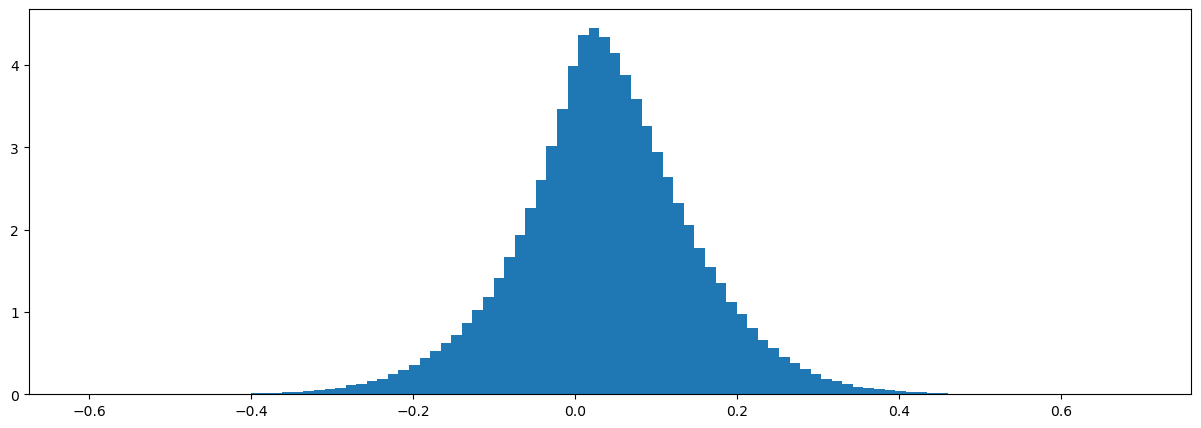

In [24]:
plt.hist(chieff_samps, density=True, bins=100)

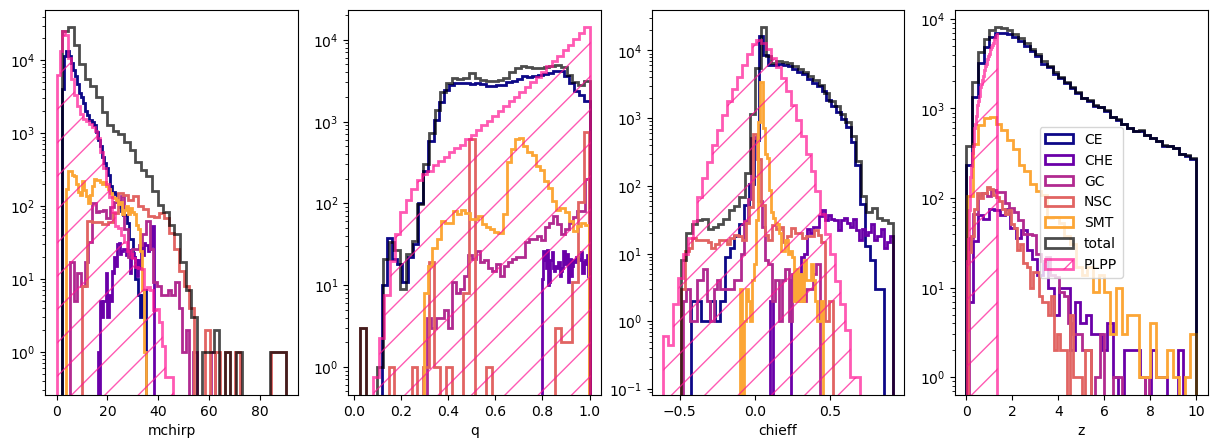

In [52]:
plt.rcParams["figure.figsize"] = (15,5)
fig,ax=plt.subplots(1,4)
cmap = plt.colormaps['plasma']
colors = cmap(np.linspace(0, 1, 6))
PLPP_samps = [mchirp_samps, comb_intrins_samps['q'], chieff_samps, comb_intrins_samps['z']]

for cidx, channel in enumerate(channels):
    for pidx,param in enumerate(params):
        ax[pidx].hist(total_samps_ordered[samps_filled[cidx-1]:samps_filled[cidx],pidx], color=colors[cidx], histtype='step', bins=40, lw=2,\
             label=channel)
        ax[pidx].set_yscale('log')
        ax[pidx].set_xlabel(param)

for pidx,param in enumerate(params):
    ax[pidx].hist(total_samps_ordered[:,pidx], color='black', histtype='step', bins=40, lw=2, ls='-', label='total', alpha=0.7)
    ax[pidx].hist(PLPP_samps[pidx], color='deeppink', histtype='step', weights=np.ones_like(PLPP_samps[pidx])*len(total_samps_ordered[:,pidx])/len(PLPP_samps[pidx]),\
        hatch='/', bins=40, lw=2, ls='-', label='PLPP', alpha=0.7)
plt.legend()

In [27]:
np.min(total_samps_ordered[:,0])

2.2595643710329076

In [32]:
np.min(chieff_samps)

-0.6096828525759653

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


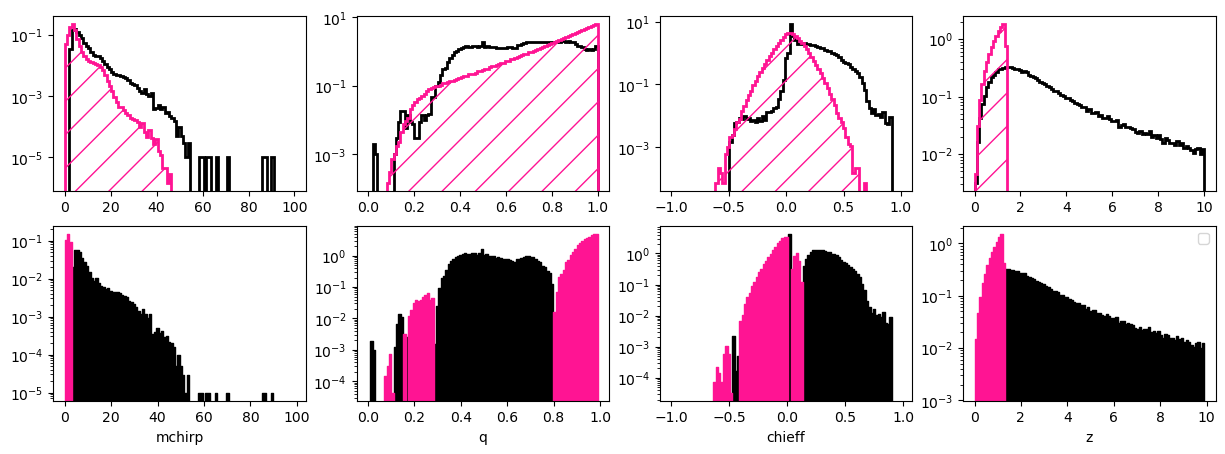

In [33]:
fig,ax=plt.subplots(2,4)
bins =np.array([np.linspace(0,100,100), np.linspace(0,1,100), np.linspace(-1,1,100), np.linspace(0,10,100)])

for pidx,param in enumerate(params):
    ax[0,pidx].hist(total_samps_ordered[:,pidx], color='black', histtype='step', bins=bins[pidx], lw=2, ls='-',\
        density=True, label='total', alpha=1)
    ax[0,pidx].hist(PLPP_samps[pidx], color='deeppink', histtype='step', density=True,\
        hatch='/', bins=bins[pidx], lw=2, ls='-', label='PLPP', alpha=1)
    ax[0,pidx].set_yscale('log')
    flow_hist, _ = np.histogram(total_samps[:,pidx], bins=bins[pidx], density=True)
    PLPP_hist, _ = np.histogram(PLPP_samps[pidx], bins=bins[pidx], density=True)
    ax[1,pidx].fill_between(bins[pidx][:-1], flow_hist-PLPP_hist, step="pre", color='black', alpha=1)
    ax[1,pidx].fill_between(bins[pidx][:-1], PLPP_hist-flow_hist, step="pre", color='deeppink')
    ax[1,pidx].set_yscale('log')
    ax[1,pidx].set_xlabel(param)
plt.legend()

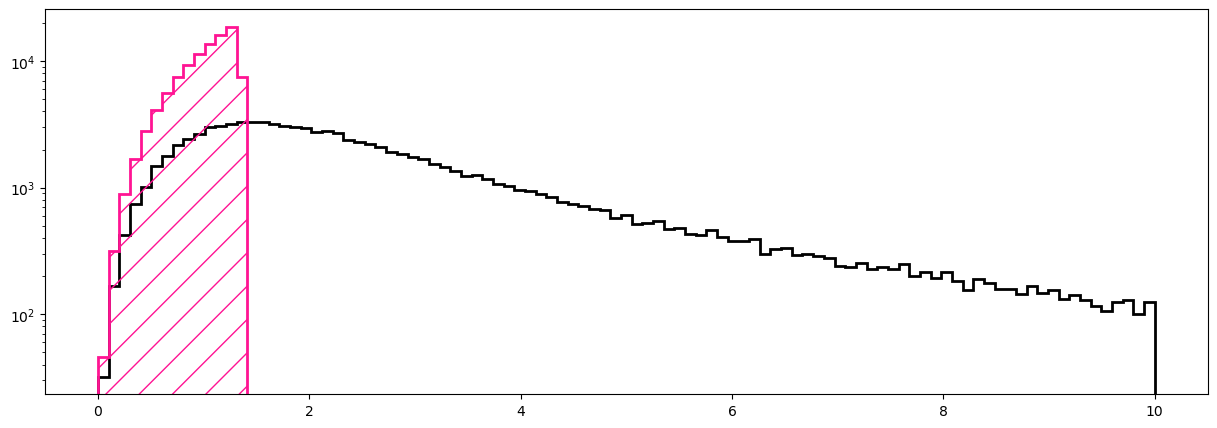

In [60]:
fig,ax=plt.subplots(1,1)
ax.hist(total_samps_ordered[:,pidx], color='black', histtype='step', bins=bins[pidx], lw=2, ls='-',\
        label='total', alpha=1)
ax.hist(PLPP_samps[pidx], color='deeppink', histtype='step', weights=np.ones_like(PLPP_samps[pidx])*len(total_samps[:,pidx])/len(PLPP_samps[pidx]),\
    hatch='/', bins=bins[3], lw=2, ls='-', label='PLPP', alpha=1)
ax.set_yscale('log')

In [61]:
np.diff(bins[3])

array([0.1010101, 0.1010101, 0.1010101, 0.1010101, 0.1010101, 0.1010101,
       0.1010101, 0.1010101, 0.1010101, 0.1010101, 0.1010101, 0.1010101,
       0.1010101, 0.1010101, 0.1010101, 0.1010101, 0.1010101, 0.1010101,
       0.1010101, 0.1010101, 0.1010101, 0.1010101, 0.1010101, 0.1010101,
       0.1010101, 0.1010101, 0.1010101, 0.1010101, 0.1010101, 0.1010101,
       0.1010101, 0.1010101, 0.1010101, 0.1010101, 0.1010101, 0.1010101,
       0.1010101, 0.1010101, 0.1010101, 0.1010101, 0.1010101, 0.1010101,
       0.1010101, 0.1010101, 0.1010101, 0.1010101, 0.1010101, 0.1010101,
       0.1010101, 0.1010101, 0.1010101, 0.1010101, 0.1010101, 0.1010101,
       0.1010101, 0.1010101, 0.1010101, 0.1010101, 0.1010101, 0.1010101,
       0.1010101, 0.1010101, 0.1010101, 0.1010101, 0.1010101, 0.1010101,
       0.1010101, 0.1010101, 0.1010101, 0.1010101, 0.1010101, 0.1010101,
       0.1010101, 0.1010101, 0.1010101, 0.1010101, 0.1010101, 0.1010101,
       0.1010101, 0.1010101, 0.1010101, 0.1010101, 

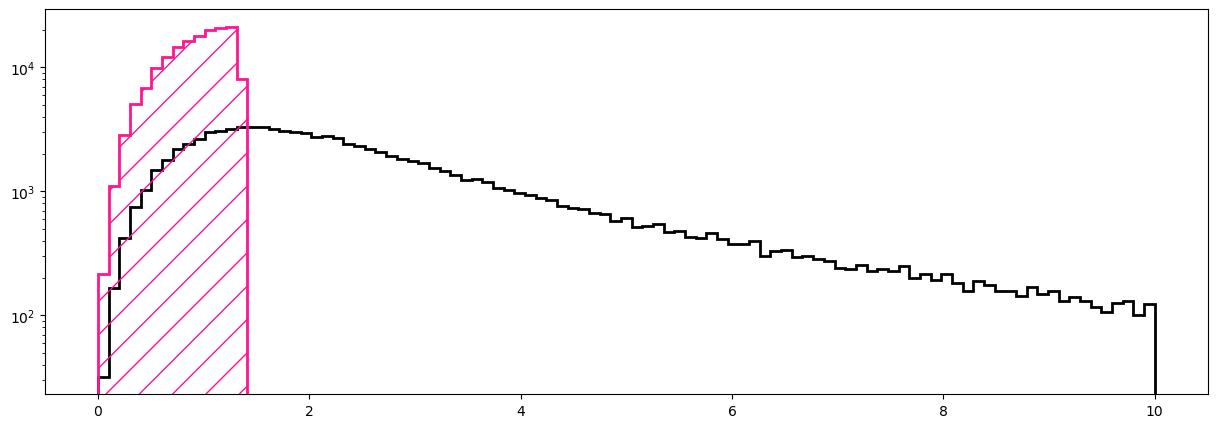

In [58]:
fig,ax=plt.subplots(1,1)
ax.hist(total_samps_ordered[:,pidx], color='black', histtype='step', bins=bins[pidx], lw=2, ls='-',\
        label='total', alpha=1)
ax.hist(total_samps_ordered[total_samps_ordered[:,3]<1.35,pidx], color='deeppink', histtype='step', weights=np.ones_like(total_samps_ordered[total_samps_ordered[:,3]<1.35,pidx])/len(total_samps[:,pidx])*len(PLPP_samps[pidx]),\
    hatch='/', bins=bins[3], lw=2, ls='-', label='PLPP', alpha=1)
ax.set_yscale('log')